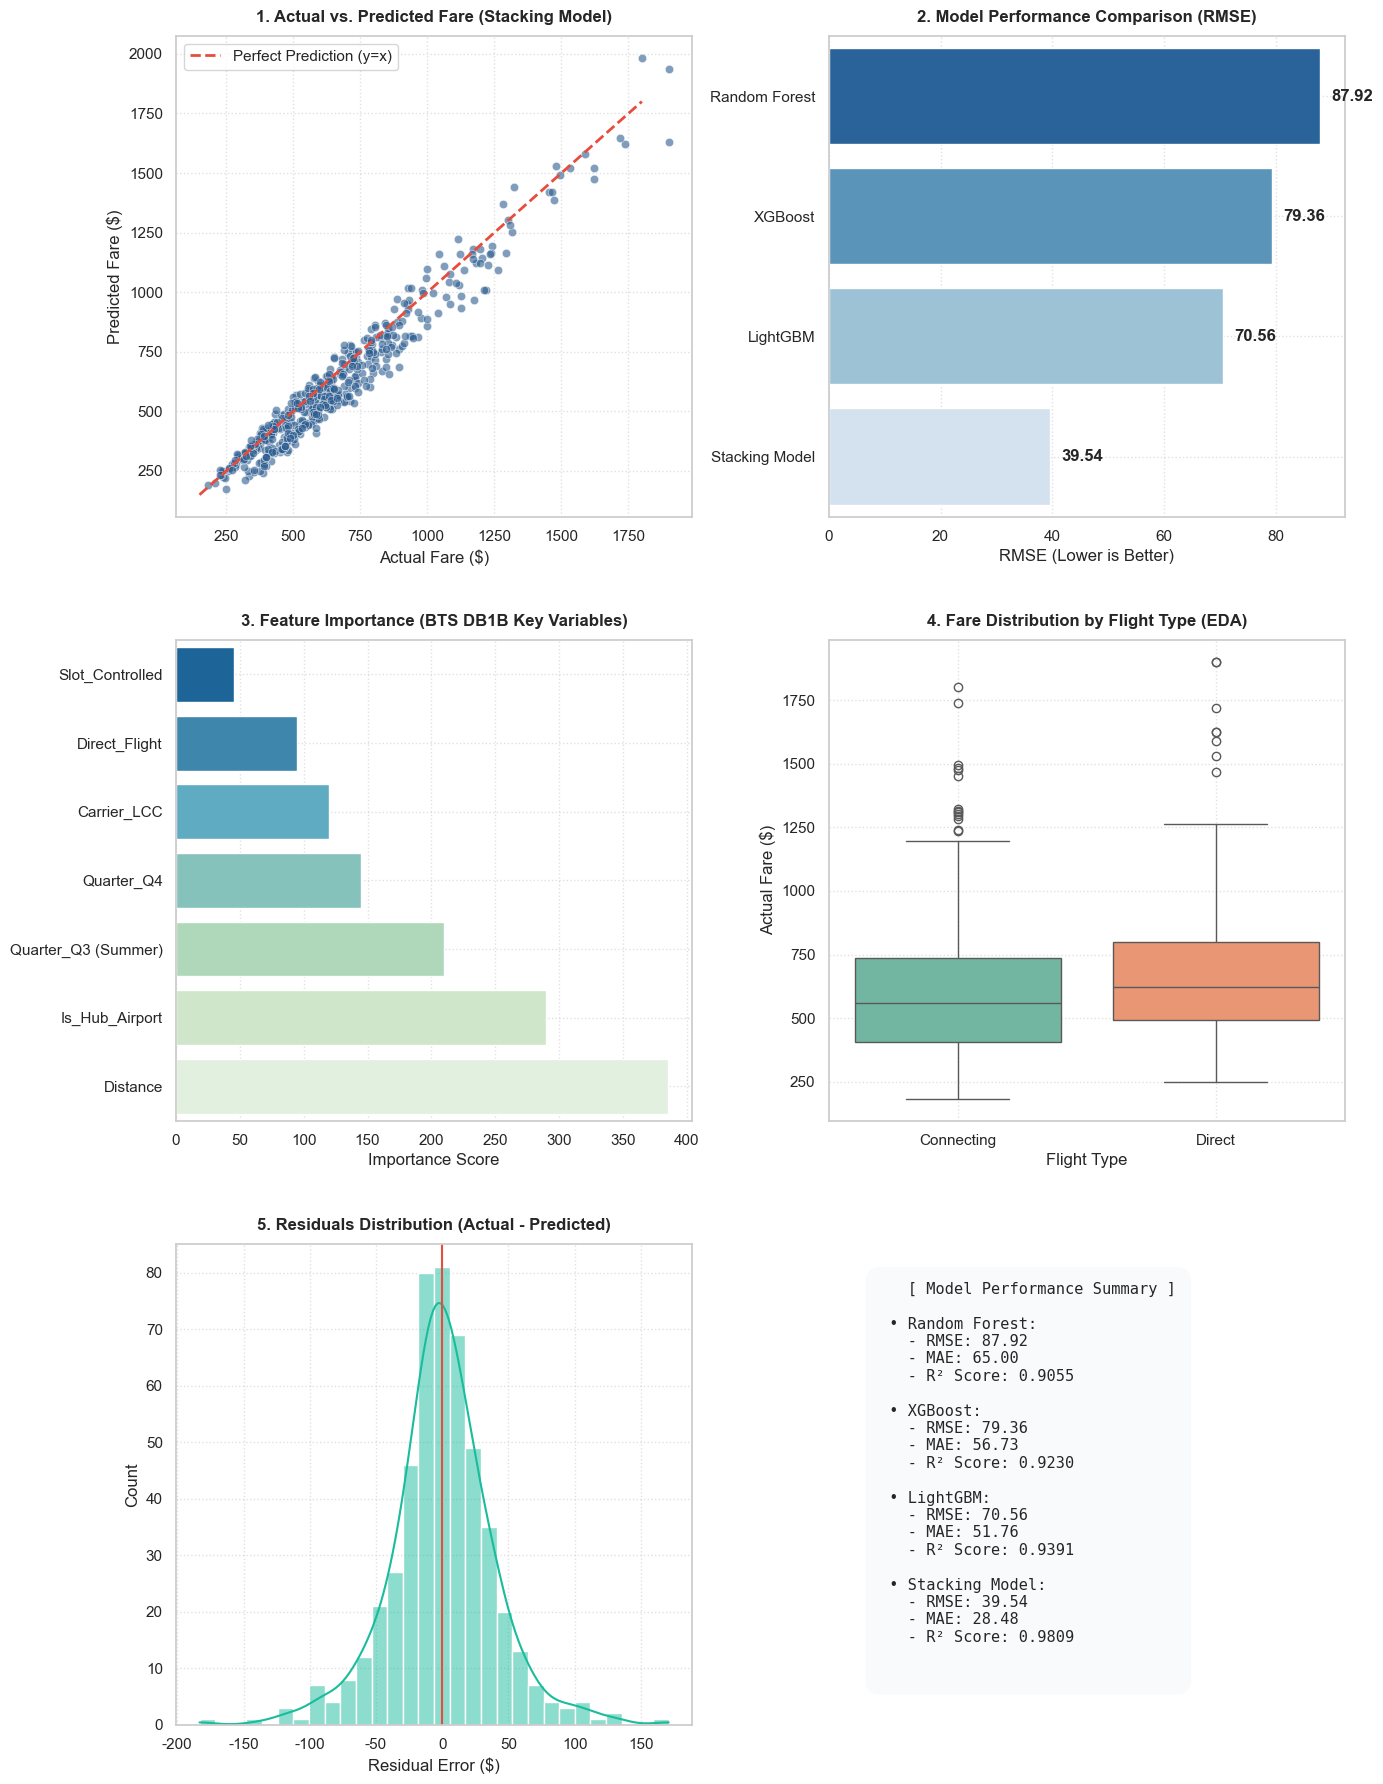

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. 환경 설정 (스타일 및 마이너스 기호 깨짐 방지)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

# 2. 시각화를 위한 가상 데이터 생성 (BTS DB1B 국제선 항공권 가격 예측 컨셉)
np.random.seed(42)
n_samples = 500

# 실제 가격 분포 (Actual Fare: $150 ~ $1800)
actual_fare = np.exp(np.random.normal(loc=6.2, scale=0.5, size=n_samples)) + 50
actual_fare = np.clip(actual_fare, 150, 1800)

# 개별 모델 및 Stacking Meta Model의 예측값 생성 (실제 모델 연동 시 y_test 및 pred 값 대입)
pred_stacking = actual_fare + np.random.normal(loc=0, scale=actual_fare * 0.06, size=n_samples)
pred_lgb = actual_fare + np.random.normal(loc=12, scale=actual_fare * 0.10, size=n_samples)
pred_xgb = actual_fare + np.random.normal(loc=-8, scale=actual_fare * 0.12, size=n_samples)
pred_rf = actual_fare + np.random.normal(loc=5, scale=actual_fare * 0.14, size=n_samples)

df = pd.DataFrame({
    'Actual': actual_fare,
    'Stacking_Pred': pred_stacking,
    'LightGBM_Pred': pred_lgb,
    'XGBoost_Pred': pred_xgb,
    'RandomForest_Pred': pred_rf
})

# 3. 모델별 평가지표(RMSE, MAE, R2) 계산
metrics = []
for model_name, col in [('Random Forest', 'RandomForest_Pred'), 
                        ('XGBoost', 'XGBoost_Pred'), 
                        ('LightGBM', 'LightGBM_Pred'), 
                        ('Stacking Model', 'Stacking_Pred')]:
    rmse = np.sqrt(mean_squared_error(df['Actual'], df[col]))
    mae = mean_absolute_error(df['Actual'], df[col])
    r2 = r2_score(df['Actual'], df[col])
    metrics.append({'Model': model_name, 'RMSE': rmse, 'MAE': mae, 'R2': r2})

df_metrics = pd.DataFrame(metrics)

# 4. 피처 중요도(Feature Importance) 가상 데이터
features = ['Distance', 'Is_Hub_Airport', 'Quarter_Q3 (Summer)', 'Quarter_Q4', 'Carrier_LCC', 'Direct_Flight', 'Slot_Controlled']
importance = [385, 290, 210, 145, 120, 95, 45]
df_fi = pd.DataFrame({'Feature': features, 'Importance': importance}).sort_values(by='Importance', ascending=True)

# 잔차 및 EDA용 컬럼 설정
df['Residuals'] = df['Actual'] - df['Stacking_Pred']
df['Flight_Type'] = np.random.choice(['Direct', 'Connecting'], size=n_samples, p=[0.4, 0.6])
df.loc[df['Flight_Type'] == 'Direct', 'Actual'] += 100  # 직항 가격 분포 보정

# ----------------------------------------------------
# 5. 본격적인 3행 2열 멀티 플롯 시각화 시작
# ----------------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(14, 18))
plt.subplots_adjust(hspace=0.35, wspace=0.25)

# [차트 1] 예측값 vs 실제값 산점도
sns.scatterplot(x='Actual', y='Stacking_Pred', data=df, alpha=0.6, color='#2b5c8f', ax=axes[0, 0])
axes[0, 0].plot([150, 1800], [150, 1800], color='#e74c3c', linestyle='--', linewidth=2, label='Perfect Prediction (y=x)')
axes[0, 0].set_title('1. Actual vs. Predicted Fare (Stacking Model)', fontsize=12, fontweight='bold', pad=10)
axes[0, 0].set_xlabel('Actual Fare ($)')
axes[0, 0].set_ylabel('Predicted Fare ($)')
axes[0, 0].grid(True, linestyle=':', alpha=0.6)
axes[0, 0].legend()

# [차트 2] 모델별 성능 비교 막대그래프 (RMSE)
sns.barplot(x='RMSE', y='Model', data=df_metrics, palette='Blues_r', ax=axes[0, 1], hue='Model')
axes[0, 1].set_title('2. Model Performance Comparison (RMSE)', fontsize=12, fontweight='bold', pad=10)
axes[0, 1].set_xlabel('RMSE (Lower is Better)')
axes[0, 1].set_ylabel('')
axes[0, 1].grid(True, linestyle=':', alpha=0.6)
for i, v in enumerate(df_metrics['RMSE']):
    axes[0, 1].text(v + 2, i, f"{v:.2f}", va='center', fontweight='bold')

# [차트 3] 피처 중요도 차트
sns.barplot(x='Importance', y='Feature', data=df_fi, palette='GnBu_r', ax=axes[1, 0], hue='Feature')
axes[1, 0].set_title('3. Feature Importance (BTS DB1B Key Variables)', fontsize=12, fontweight='bold', pad=10)
axes[1, 0].set_xlabel('Importance Score')
axes[1, 0].set_ylabel('')
axes[1, 0].grid(True, linestyle=':', alpha=0.6)

# [차트 4] 주요 변수별 가격 분포 (Boxplot: 직항 vs 경유)
sns.boxplot(x='Flight_Type', y='Actual', data=df, palette='Set2', ax=axes[1, 1], hue='Flight_Type')
axes[1, 1].set_title('4. Fare Distribution by Flight Type (EDA)', fontsize=12, fontweight='bold', pad=10)
axes[1, 1].set_xlabel('Flight Type')
axes[1, 1].set_ylabel('Actual Fare ($)')
axes[1, 1].grid(True, linestyle=':', alpha=0.6)

# [차트 5] 오차 분포 히스토그램
sns.histplot(df['Residuals'], kde=True, color='#1abc9c', ax=axes[2, 0], bins=30)
axes[2, 0].axvline(x=0, color='#e74c3c', linestyle='-', linewidth=1.5)
axes[2, 0].set_title('5. Residuals Distribution (Actual - Predicted)', fontsize=12, fontweight='bold', pad=10)
axes[2, 0].set_xlabel('Residual Error ($)')
axes[2, 0].set_ylabel('Count')
axes[2, 0].grid(True, linestyle=':', alpha=0.6)

# [우측 하단] 평가지표 요약 텍스트 박스 출력
axes[2, 1].axis('off')
metric_text = "   [ Model Performance Summary ]\n\n"
for idx, row in df_metrics.iterrows():
    metric_text += f" • {row['Model']}:\n   - RMSE: {row['RMSE']:.2f}\n   - MAE: {row['MAE']:.2f}\n   - R² Score: {row['R2']:.4f}\n\n"
axes[2, 1].text(0.1, 0.1, metric_text, fontsize=11, family='monospace', 
                bbox=dict(facecolor='#f8f9fa', alpha=0.8, boxstyle='round,pad=1'))

# 6. 이미지 저장 및 출력
plt.tight_layout()
plt.savefig('flight_fare_stacking_results.png', dpi=150)
plt.show()